In [1]:
import os
import shutil
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset, random_split
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split

#### Define two folders: "fresh" and "spoiled" which will contain the respective images of fruits (Run this only once)

In [ ]:
# SRC_DIR = r"D:\Harvest_Data\FRUITS"
# DST_DIR = r"D:\Harvest_Data\FRUIT_BINARY"

# fresh_dir = os.path.join(DST_DIR, "fresh")
# spoiled_dir = os.path.join(DST_DIR, "spoiled")

# os.makedirs(fresh_dir, exist_ok=True)
# os.makedirs(spoiled_dir, exist_ok=True)

# for folder in os.listdir(SRC_DIR):
#     src_folder_path = os.path.join(SRC_DIR, folder)

#     if not os.path.isdir(src_folder_path):
#         continue

#     # Decide target label
#     if folder.startswith("F_"):
#         target_dir = fresh_dir
#     elif folder.startswith("S_"):
#         target_dir = spoiled_dir
#     else:
#         continue

#     for img_name in os.listdir(src_folder_path):
#         src_img_path = os.path.join(src_folder_path, img_name)

#         if not os.path.isfile(src_img_path):
#             continue

#         # Make filename unique
#         new_img_name = f"{folder}_{img_name}"

#         dst_img_path = os.path.join(target_dir, new_img_name)

#         shutil.copy(src_img_path, dst_img_path)


#### Define transforms

In [2]:
train_transform = transforms.Compose([
    transforms.RandomCrop(224, padding=16),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(7),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


In [3]:
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])


In [4]:
# Load dataset WITHOUT transforms (for indexing only)
data_dir = r"FreshHarvest_Dataset/FRUIT_BINARY"

base_dataset = datasets.ImageFolder(
    root=data_dir,
    transform=None
)

samples = base_dataset.samples  # [(path, label), ...]


#### Extract fruit names from filenames

In [5]:
from collections import defaultdict
import os

fruit_to_indices = defaultdict(list)

for idx, (path, label) in enumerate(samples):
    filename = os.path.basename(path)
    
    # Example: F_Mango_1.jpg → Mango
    fruit_name = filename.split("_")[1]
    
    fruit_to_indices[(fruit_name, label)].append(idx)


In [6]:
fruit_to_indices.keys()

dict_keys([('Banana', 0), ('Lemon', 0), ('Lulo', 0), ('Mango', 0), ('Orange', 0), ('Strawberry', 0), ('Tamarillo', 0), ('Tomato', 0), ('Banana', 1), ('Lemon', 1), ('Lulo', 1), ('Mango', 1), ('Orange', 1), ('Strawberry', 1), ('Tamarillo', 1), ('Tomato', 1)])

#### Group-aware split (NO leakage) - Do the split inside each (fruit, class) group.

In [7]:
from sklearn.model_selection import train_test_split

train_idx, val_idx, test_idx = [], [], []

for (fruit, label), indices in fruit_to_indices.items():
    
    # 70% train, 15% val, 15% test
    tr, temp = train_test_split(
        indices,
        test_size=0.30,
        random_state=42
    )
    
    val, te = train_test_split(
        temp,
        test_size=0.50,
        random_state=42
    )
    
    train_idx.extend(tr)
    val_idx.extend(val)
    test_idx.extend(te)


#### Create datasets WITH transforms

In [8]:
train_dataset = datasets.ImageFolder(
    root=data_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=data_dir,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=data_dir,
    transform=eval_transform
)


#### Create subsets

In [9]:
from torch.utils.data import Subset

train_subset = Subset(train_dataset, train_idx)
val_subset   = Subset(val_dataset, val_idx)
test_subset  = Subset(test_dataset, test_idx)

#### Dataloaders

In [10]:
import os
from torch.utils.data import DataLoader

NUM_WORKERS = min(4, os.cpu_count())

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


#### Sanity checks

In [11]:
print("Train:", len(train_subset))
print("Val:", len(val_subset))
print("Test:", len(test_subset))

Train: 11200
Val: 2400
Test: 2400


In [12]:
def count_fruits(indices):
    fruits = set()
    for i in indices:
        fname = os.path.basename(samples[i][0])
        fruits.add(fname.split("_")[1])
    return fruits

print("Train fruits:", count_fruits(train_idx))
print("Val fruits:", count_fruits(val_idx))
print("Test fruits:", count_fruits(test_idx))

Train fruits: {'Mango', 'Strawberry', 'Tomato', 'Orange', 'Banana', 'Lulo', 'Tamarillo', 'Lemon'}
Val fruits: {'Mango', 'Strawberry', 'Tomato', 'Orange', 'Banana', 'Lulo', 'Tamarillo', 'Lemon'}
Test fruits: {'Mango', 'Strawberry', 'Tomato', 'Orange', 'Banana', 'Lulo', 'Tamarillo', 'Lemon'}


#### Randomly pick 10 images from first batch of train_loader and visualize images along with their labels

In [15]:
# Get first batch from train_loader
images, labels = next(iter(train_loader))

# Randomly pick 10 indices
idxs = random.sample(range(images.size(0)), 10)

In [16]:
# Un-normalization function

mean = np.array([0.5, 0.5, 0.5])
std  = np.array([0.5, 0.5, 0.5])

def unnormalize(img):
    img = img.numpy().transpose(1, 2, 0)   # C,H,W → H,W,C
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

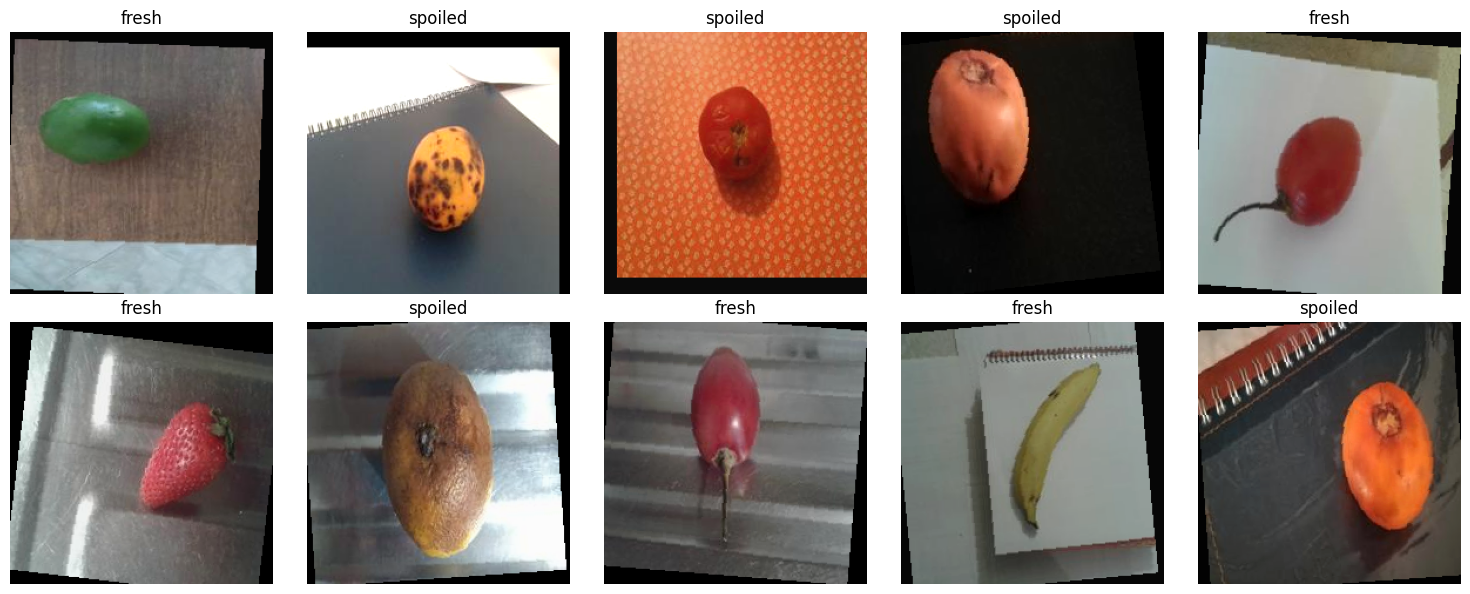

In [17]:
# Plot images in a grid

plt.figure(figsize=(15, 6))

for i, idx in enumerate(idxs):
    plt.subplot(2, 5, i + 1)
    plt.imshow(unnormalize(images[idx].cpu()))
    plt.title(train_dataset.classes[labels[idx]])
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Model building - No transfer learning, no regularization

In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [19]:
class BaseCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaseCNN, self).__init__()

        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3,3), padding='same'), # (16, 224, 224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)), # (16, 112, 112)

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3,3), padding='same'), # (32, 112, 112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)), # (32, 56, 56)

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), padding='same'), # (64, 56, 56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)), # (64, 28, 28)

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3,3), padding='same'), # (128, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)) # (128, 14, 14)
        
        )

        self.flatten = nn.Flatten()

        self.fc_layer = nn.Sequential(
            nn.Linear(128*14*14, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )


    def forward(self, x):
        x = self.network(x)
        x = self.flatten(x)
        x = self.fc_layer(x)

        return x            

In [20]:
model = BaseCNN(num_classes=2).to(device)
print(model)

BaseCNN(
  (network): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_layer): Sequential(
    (0): Linear(in_features=25088, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # Common defaults: betas=(0.9, 0.999), eps=1e-8

#### Training & evaluation function

In [22]:
def train_and_validate(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs
):
    """
    Trains and validates the model.
    Prints train loss and validation loss every 10 epochs.
    """

    assert epochs % 10 == 0, "Epochs must be in steps of 10"

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # --------------------
        # Training phase
        # --------------------
        model.train()
        running_train_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --------------------
        # Validation phase (every epoch, but print every 10)
        # --------------------
        model.eval()
        running_val_loss = 0.0
        total = 0
        correct = 0

        true_labels = []
        pred_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

                _, predicted = torch.max(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                true_labels.extend(labels.cpu().numpy())
                pred_labels.extend(predicted.cpu().numpy())

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        accuracy = 100.0 * correct / total

        # --------------------
        # Logging every 10 epochs
        # --------------------
        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch+1}/{epochs}] | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {avg_val_loss:.4f} | "
                f"Val Acc: {accuracy:.2f}%"
            )

    return train_losses, val_losses, true_labels, pred_labels


In [23]:
train_losses, val_losses, true_labels, pred_labels = train_and_validate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=30
)


Epoch [10/30] | Train Loss: 0.1298 | Val Loss: 0.0926 | Val Acc: 96.17%
Epoch [20/30] | Train Loss: 0.0658 | Val Loss: 0.0736 | Val Acc: 97.25%
Epoch [30/30] | Train Loss: 0.0341 | Val Loss: 0.0197 | Val Acc: 99.12%


#### Plot the confusion matrix

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, pred_labels)

In [26]:
# class_names = full_dataset.classe  # class names
class_names = ["fresh", "spoiled"]

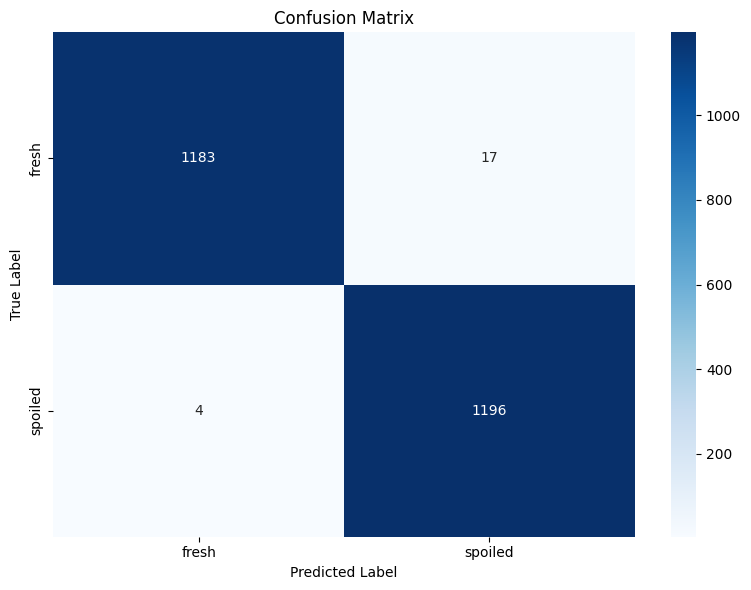

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,  # we want numbers in cells
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


#### Evaluate on the test dataset

In [30]:
model.eval()

test_loss = 0.0
correct = 0
total = 0

true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # store for confusion matrix / analysis
        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predicted.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_accuracy = 100.0 * correct / total

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Loss: 0.0314
Test Accuracy: 98.79%


#### Export model

In [31]:
import torch

MODEL_PATH = "fruits_freshness_classifier.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": train_dataset.class_to_idx
}, MODEL_PATH)

print("Model saved successfully!")


Model saved successfully!
